# **Reading in the excel file**

In [20]:
import pandas as pd

#Loading in the excel file
df = pd.read_excel('/content/Bootcamp_project_Data.xlsx')

#Displaying the first 5 rows of the dataset for easier readability
df.head()


,number,First name,Faculty,Department,Week_1,Week_2,Week_3,Week_4,Week_5,Week_6,Week_7,Week_8,Week_9,Week_10,Week_11,Week_12,Week_13
0,1,A.k.m,AB,NINF,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2,Abdul,AB,NINF,0,1,1,1,1,1,1,1,1,1,1,1,1
2,3,Abdullah,AB,NINF,1,1,1,1,1,1,1,1,1,1,1,1,1
3,4,Abdur,AB,NINF,0,1,1,1,1,1,1,1,1,0,1,1,1
4,5,Abu,AB,NINF,0,0,0,0,0,0,0,0,0,0,0,0,0


In [41]:
#Last 5 rows of the dataset
df.tail()

,number,First name,Faculty,Department,Week_1,Week_2,Week_3,Week_4,Week_5,Week_6,Week_7,Week_8,Week_9,Week_10,Week_11,Week_12,Week_13,Total_Attendance
77,78,Zarin,gh,NINF,0,0,0,0,0,0,0,0,0,0,0,0,0,0
78,79,Zeynab,gh,NEGD,1,1,0,1,1,0,1,1,1,1,1,1,1,11
79,80,Zora,gh,NINF,0,0,0,0,0,0,0,0,0,0,0,0,0,0
80,81,Zubair,gh,NEGD,0,0,1,0,0,0,0,0,0,0,0,0,0,1
81,82,Ram Kumar,NaN,NaN,0,0,1,1,1,1,0,0,0,0,0,0,0,4


# **Attendance Report data retrival**

In [33]:
#Function for retriving the attendence report
def attendance_reports(df):

    # The Top 5 students with highest attendance
    df['Total_Attendance'] = df.loc[:, 'Week_1':'Week_13'].sum(axis=1)
    top_5_students = df.nlargest(5, 'Total_Attendance')[['First name', 'Total_Attendance']]

    # The week with highest attendance
    weekly_attendance = df.loc[:, 'Week_1':'Week_13'].sum()
    highest_attendance_week = weekly_attendance.idxmax()

    # The number of faculties and the student per faculty
    faculty_counts = df['Faculty'].value_counts()

    #The number of Students whose name Starts with M
    name_starts_with_m = df[df['First name'].str.startswith('M')].shape[0]

    return top_5_students, highest_attendance_week, faculty_counts, name_starts_with_m


top_5_students, highest_attendance_week, faculty_counts, students_starting_with_M = attendance_reports(df)

#Output for the top 5 students with the highest attendence
top_5_students

,First name,Total_Attendance
2,Abdullah,13
15,Basit,13
1,Abdul,12
16,Berza,12
17,Deborah,12


In [22]:
#Output for highest attendence week
print("The week with the highest attendence is:",highest_attendance_week)

The week with the highest attendence is: Week_5


In [23]:
#Output for faculty
faculty_counts

Faculty
ef    32
gh    20
cd    17
AB    12
Name: count, dtype: int64

In [24]:
print(students_starting_with_M, "students have their name starting with the letter M")

15 students have their name starting with the letter M


# **Data visualisation**

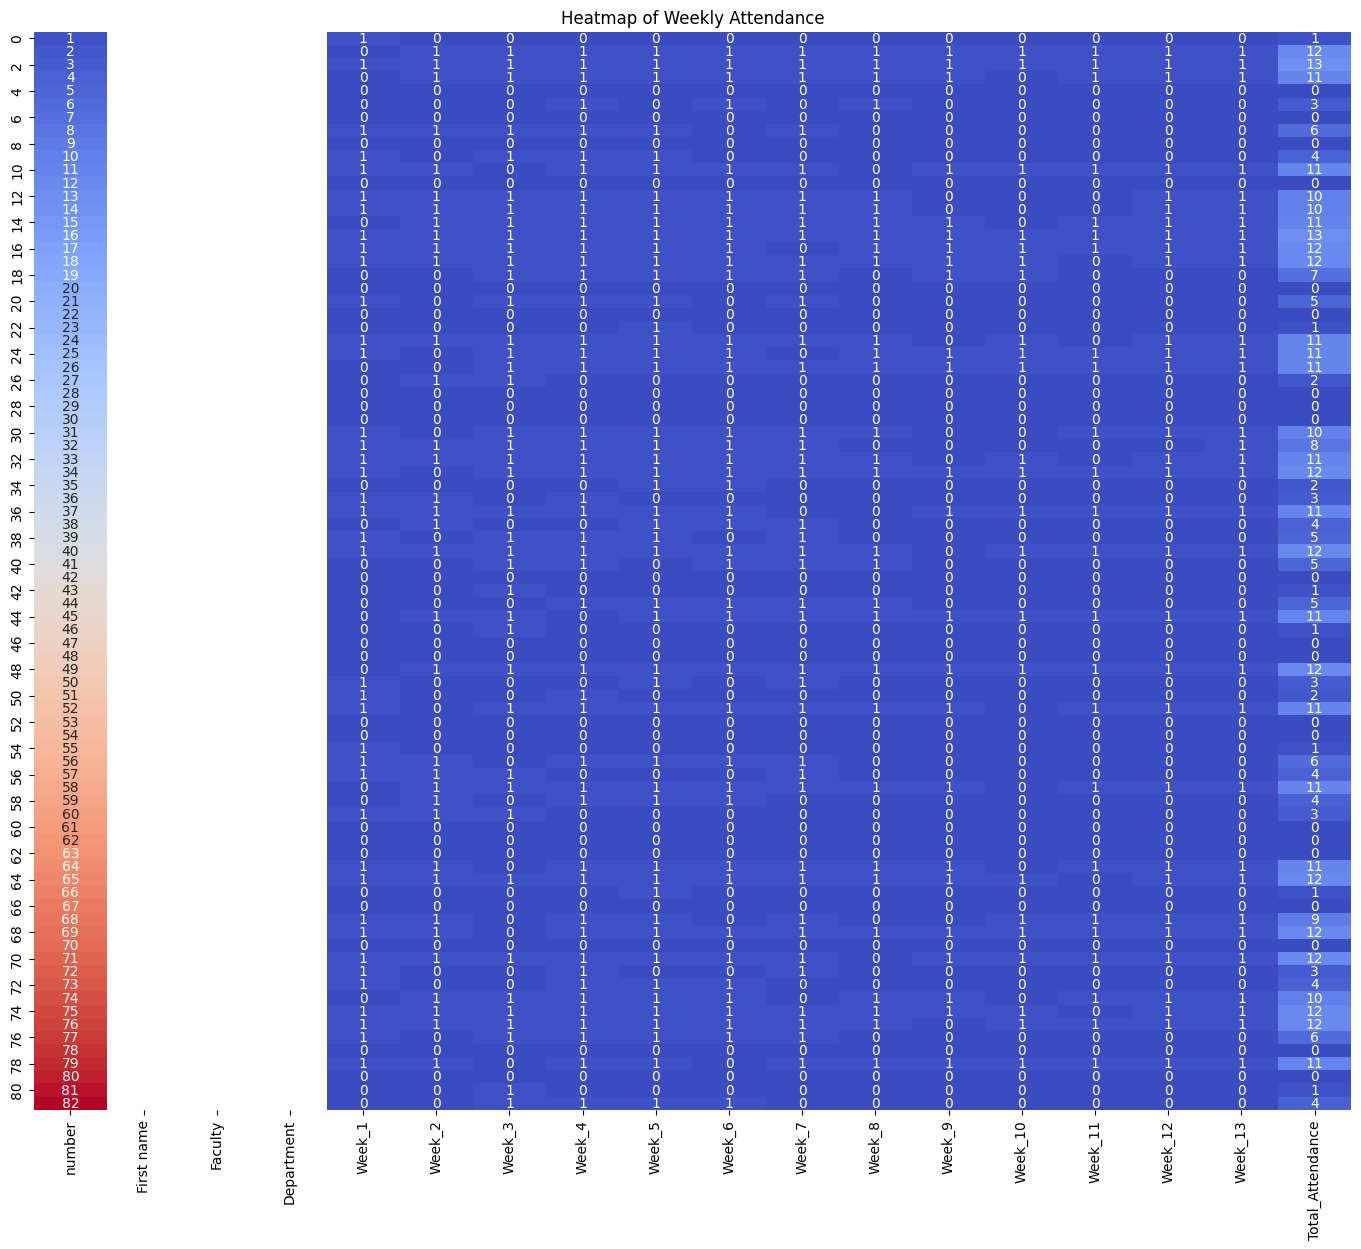

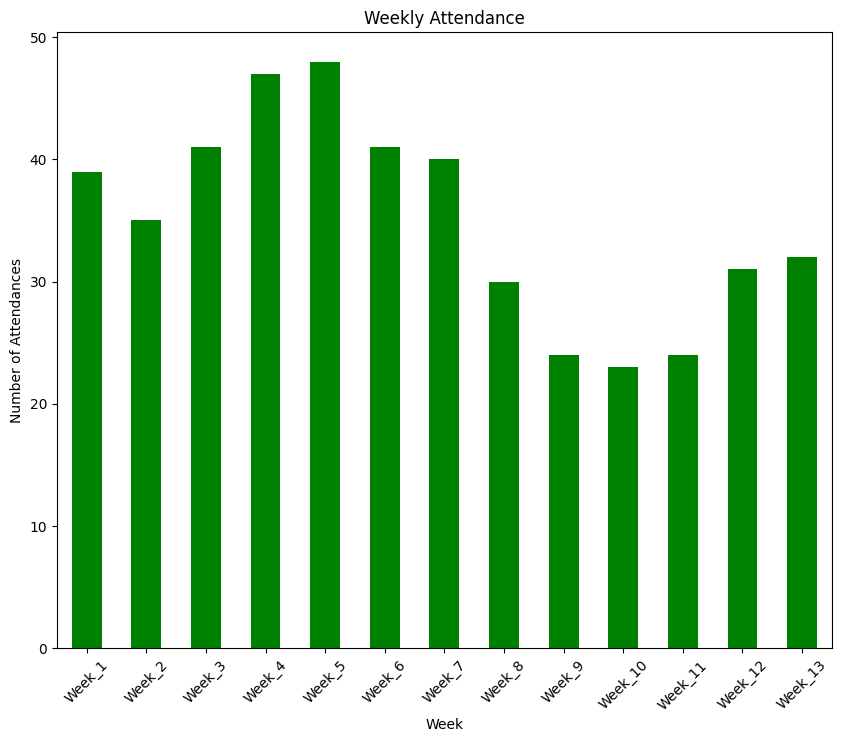

In [42]:
#Importing libraries to carry out the data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Function for visualising the data
def data_visualisation(df):

  #Heat map of the entire data visualised
  plt.figure(figsize=(17, 14))
  sns.heatmap(df.apply(pd.to_numeric, errors='coerce'), annot=True, cmap='coolwarm', cbar=False)
  plt.title('Heatmap of Weekly Attendance')
  plt.show()

  #Bar chart of weekly attendance
  plt.figure(figsize=(10, 8))
  weekly_attendance = df.loc[:, 'Week_1':'Week_13'].sum()
  weekly_attendance.plot(kind='bar', color = 'green')
  plt.title('Weekly Attendance')
  plt.xlabel('Week')
  plt.ylabel('Number of Attendances')
  plt.xticks(rotation=45)
  plt.show()


data_visualisation(df)
